# Train and analyze MDP policies on ICU-Sepsis

This notebook uses the copied baseline repository in `code/COPER/policies` and the vendored `icu_sepsis` environment already present in this project.

Workflow:

1. Configure a small but runnable training setup for the copied policy baselines.
2. Train selected methods and collect their learned policy objects.
3. Compare them with random and expert policies on rollout statistics.
4. Display trajectories and policy summaries for qualitative analysis.

The notebook is written so it can be used both for quick testing and for longer analysis runs by editing the config cell.

In [10]:
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
import os
import sys

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
POLICIES_ROOT = PROJECT_ROOT / "policies"
ICU_SEPSIS_PACKAGE_ROOT = PROJECT_ROOT / "icu_sepsis" / "icu_sepsis"

for path in (PROJECT_ROOT, POLICIES_ROOT, ICU_SEPSIS_PACKAGE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.chdir(POLICIES_ROOT)

import icu_sepsis  # noqa: F401
from src.algos.dqn import run_dqn
from src.algos.ppo import run_ppo
from src.algos.qlearning import run_qlearning
from src.algos.sac import run_sac
from src.algos.sarsa import run_sarsa

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

def make_args(**kwargs):
    return SimpleNamespace(**kwargs)

In [11]:
TRAIN_EPISODES = 80
EVAL_EPISODES = 150
BASE_SEED = 7
ALGORITHMS = ["qlearning", "sarsa", "dqn", "ppo", "sac"]

ALGO_RUNNERS = {
    "qlearning": run_qlearning,
    "sarsa": run_sarsa,
    "dqn": run_dqn,
    "ppo": run_ppo,
    "sac": run_sac,
}

ALGO_CONFIGS = {
    "qlearning": dict(seed=BASE_SEED + 0, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=0.0025, buffer_size=1, gamma=1.0, batch_size=1, start_e=1.0, end_e=0.001, exploration_fraction=0.1),
    "sarsa": dict(seed=BASE_SEED + 1, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=0.0025, buffer_size=1, gamma=0.99, batch_size=1, start_e=1.0, end_e=0.05, exploration_fraction=0.3),
    "dqn": dict(seed=BASE_SEED + 2, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=2.5e-4, buffer_size=2000, gamma=0.99, tau=1.0, target_network_frequency=100, batch_size=32, start_e=1.0, end_e=0.05, exploration_fraction=0.3, learning_starts=100, train_frequency=4),
    "ppo": dict(seed=BASE_SEED + 3, num_envs=1, learning_rate=2.5e-4, num_steps=128, max_episodes=TRAIN_EPISODES, num_minibatches=4, gamma=1.0, gae_lambda=0.95, update_epochs=4, norm_adv=True, clip_coef=0.2, clip_vloss=True, ent_coef=1.0, vf_coef=0.5, max_grad_norm=0.5, target_kl=None),
    "sac": dict(seed=BASE_SEED + 4, num_envs=1, max_episodes=TRAIN_EPISODES, buffer_size=5000, gamma=0.99, tau=1.0, batch_size=32, learning_starts=100, policy_lr=3e-4, q_lr=3e-4, update_frequency=4, target_network_frequency=200, alpha=0.2, autotune=True, target_entropy_scale=0.89),
}

env = gym.make("Sepsis/ICU-Sepsis-v2")
mdp = env.unwrapped
expert_pi = np.asarray(mdp.expert_policy)
sofa_scores = np.asarray(mdp.sofa_scores)
N_STATES = env.observation_space.n
N_ACTIONS = env.action_space.n
env.close()

print(f"states={N_STATES}, actions={N_ACTIONS}, train_episodes={TRAIN_EPISODES}, eval_episodes={EVAL_EPISODES}")
pd.DataFrame({"algorithm": ALGORITHMS, "config": [str(ALGO_CONFIGS[name]) for name in ALGORITHMS]})

states=716, actions=25, train_episodes=80, eval_episodes=150


,algorithm,config
0,qlearning,"{'seed': 7, 'num_envs': 1, 'max_episodes': 80,..."
1,sarsa,"{'seed': 8, 'num_envs': 1, 'max_episodes': 80,..."
2,dqn,"{'seed': 9, 'num_envs': 1, 'max_episodes': 80,..."
3,ppo,"{'seed': 10, 'num_envs': 1, 'learning_rate': 0..."
4,sac,"{'seed': 11, 'num_envs': 1, 'max_episodes': 80..."


In [12]:
def train_algorithm(name: str):
    args = make_args(**ALGO_CONFIGS[name])
    print(f"training {name}...")
    result = ALGO_RUNNERS[name](args, use_tensorboard=False, use_wandb=False, return_agent=True)
    result["name"] = name
    return result


def training_summary(results):
    rows = []
    for result in results:
        rows.append(
            {
                "algorithm": result["name"],
                "episodes": int(len(result["returns"])),
                "mean_train_return_last_20": float(np.mean(result["returns"][-20:])),
                "mean_train_discounted_return_last_20": float(np.mean(result["discounted_returns"][-20:])),
                "mean_train_length_last_20": float(np.mean(result["num_steps"][-20:])),
            }
        )
    return pd.DataFrame(rows).sort_values("algorithm").reset_index(drop=True)


results = [train_algorithm(name) for name in ALGORITHMS]
train_df = training_summary(results)
train_df

training qlearning...
Number of States: 716, Number of actions: 25
training sarsa...
Number of States: 716, Number of actions: 25
Mean Q Value: 0.0
SPS: 1567, Episode: 9, Step: 100, Return: 1.0, Episode length: 5
Mean Q Value: 0.0
SPS: 1455, Episode: 16, Step: 200, Return: 1.0, Episode length: 39
Mean Q Value: 0.0
SPS: 1451, Episode: 24, Step: 300, Return: 1.0, Episode length: 27
Mean Q Value: 0.0
SPS: 1481, Episode: 29, Step: 400, Return: 1.0, Episode length: 2
Mean Q Value: 0.0
SPS: 1494, Episode: 42, Step: 500, Return: 1.0, Episode length: 7
Mean Q Value: 0.0
SPS: 1488, Episode: 50, Step: 600, Return: 1.0, Episode length: 1
Mean Q Value: 0.0
SPS: 1494, Episode: 59, Step: 700, Return: 1.0, Episode length: 15
Mean Q Value: -3.307397378193855e-08
SPS: 1507, Episode: 67, Step: 800, Return: 1.0, Episode length: 1
Mean Q Value: 0.05748683214187622
SPS: 1512, Episode: 80, Step: 900, Return: 0.0, Episode length: 3
training dqn...
Number of States: 716, Number of actions: 25
SPS: 4284, Episo

,algorithm,episodes,mean_train_return_last_20,mean_train_discounted_return_last_20,mean_train_length_last_20
0,dqn,80,0.70,0.642121,10.40
1,ppo,80,0.80,0.800000,10.40
2,qlearning,80,0.90,0.900000,9.70
3,sac,80,0.75,0.667264,12.55
4,sarsa,80,0.75,0.694067,7.35


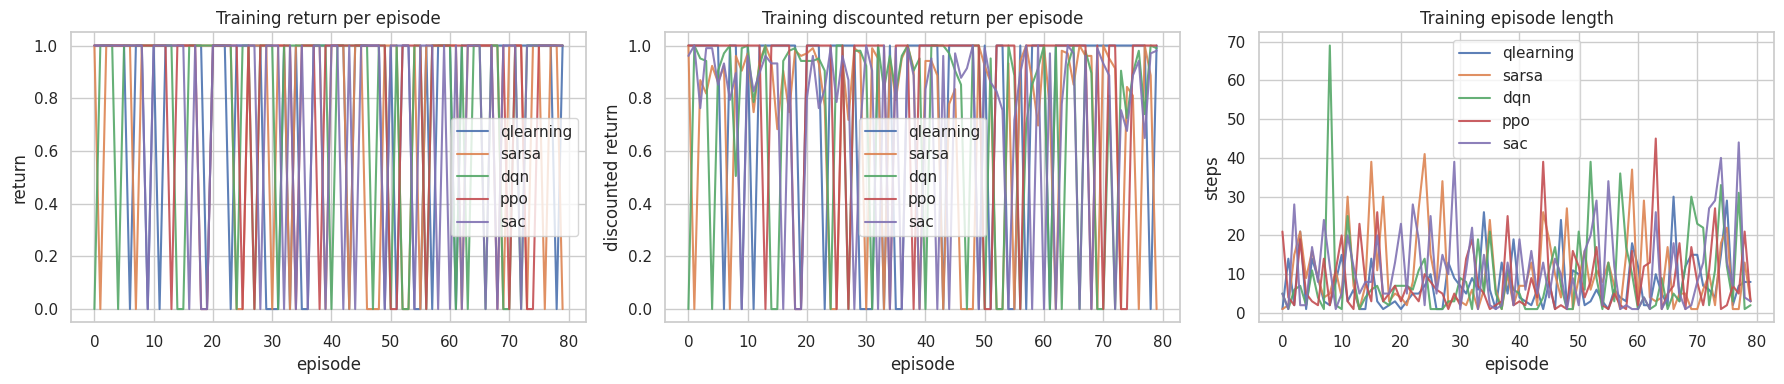

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for result in results:
    axes[0].plot(result["returns"], alpha=0.9, label=result["name"])
    axes[1].plot(result["discounted_returns"], alpha=0.9, label=result["name"])
    axes[2].plot(result["num_steps"], alpha=0.9, label=result["name"])

axes[0].set_title("Training return per episode")
axes[1].set_title("Training discounted return per episode")
axes[2].set_title("Training episode length")
axes[0].set_xlabel("episode")
axes[1].set_xlabel("episode")
axes[2].set_xlabel("episode")
axes[0].set_ylabel("return")
axes[1].set_ylabel("discounted return")
axes[2].set_ylabel("steps")
for ax in axes:
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [14]:
def encode_single_state(state: int, n_states: int) -> torch.Tensor:
    return torch.nn.functional.one_hot(torch.tensor([state]), num_classes=n_states).float()


def single_action_mask(info: dict, n_actions: int) -> torch.Tensor:
    mask = torch.zeros((1, n_actions), dtype=torch.float32)
    mask[0, info["admissible_actions"]] = 1.0
    return mask


def greedy_policy_from_result(result):
    model = result["agent"]
    algo = result["algo"]
    n_states = result["n_states"]
    n_actions = result["n_actions"]

    def policy(state: int, info: dict) -> int:
        obs = encode_single_state(int(state), n_states)
        mask = single_action_mask(info, n_actions)
        with torch.no_grad():
            if algo in {"qlearning", "sarsa", "dqn"}:
                q_values = model(obs, mask)
                return int(torch.argmax(q_values, dim=1).item())
            logits = model.actor(obs)
            logits = logits - ((1 - mask) * 1e10)
            return int(torch.argmax(logits, dim=1).item())

    return policy


def rollout_policy(policy_name: str, policy_fn, episodes: int, seed: int):
    env = gym.make("Sepsis/ICU-Sepsis-v2")
    traces = []
    try:
        for episode_idx in range(episodes):
            state, info = env.reset(seed=seed + episode_idx)
            done = False
            total_reward = 0.0
            episode_length = 0
            trace = {
                "policy": policy_name,
                "states": [int(state)],
                "actions": [],
                "rewards": [],
                "sofa": [float(env.unwrapped.sofa_scores[int(state)])],
            }
            while not done:
                action = int(policy_fn(int(state), info))
                next_state, reward, terminated, truncated, info = env.step(action)
                state = int(next_state)
                total_reward += float(reward)
                episode_length += 1
                trace["actions"].append(action)
                trace["rewards"].append(float(reward))
                trace["states"].append(state)
                trace["sofa"].append(float(env.unwrapped.sofa_scores[state]))
                done = bool(terminated or truncated)
            trace["episode_return"] = total_reward
            trace["episode_length"] = episode_length
            traces.append(trace)
    finally:
        env.close()
    return traces


def summarize_rollouts(policy_name: str, traces):
    returns = np.array([trace["episode_return"] for trace in traces], dtype=float)
    lengths = np.array([trace["episode_length"] for trace in traces], dtype=float)
    return {
        "policy": policy_name,
        "mean_return": float(returns.mean()),
        "std_return": float(returns.std(ddof=0)),
        "mean_length": float(lengths.mean()),
        "survival_rate": float((returns > 0).mean()),
    }


evaluation_rows = []
traces_by_policy = {}

random_policy = lambda state, info: int(np.random.choice(info["admissible_actions"]))
expert_policy = lambda state, info: int(np.random.choice(expert_pi.shape[1], p=expert_pi[state]))

for name, policy_fn, seed in [
    ("random", random_policy, BASE_SEED),
    ("expert", expert_policy, BASE_SEED + 100),
]:
    traces = rollout_policy(name, policy_fn, episodes=EVAL_EPISODES, seed=seed)
    evaluation_rows.append(summarize_rollouts(name, traces))
    traces_by_policy[name] = traces

for offset, result in enumerate(results):
    policy_fn = greedy_policy_from_result(result)
    traces = rollout_policy(result["name"], policy_fn, episodes=EVAL_EPISODES, seed=BASE_SEED + 200 + offset)
    evaluation_rows.append(summarize_rollouts(result["name"], traces))
    traces_by_policy[result["name"]] = traces

eval_df = pd.DataFrame(evaluation_rows).sort_values("mean_return", ascending=False).reset_index(drop=True)
eval_df

,policy,mean_return,std_return,mean_length,survival_rate
0,expert,0.806667,0.394912,9.293333,0.806667
1,qlearning,0.800000,0.400000,6.680000,0.800000
2,random,0.793333,0.404914,8.960000,0.793333
3,sarsa,0.793333,0.404914,6.566667,0.793333
4,dqn,0.793333,0.404914,7.453333,0.793333
5,ppo,0.786667,0.409661,7.420000,0.786667
6,sac,0.760000,0.427083,8.606667,0.760000


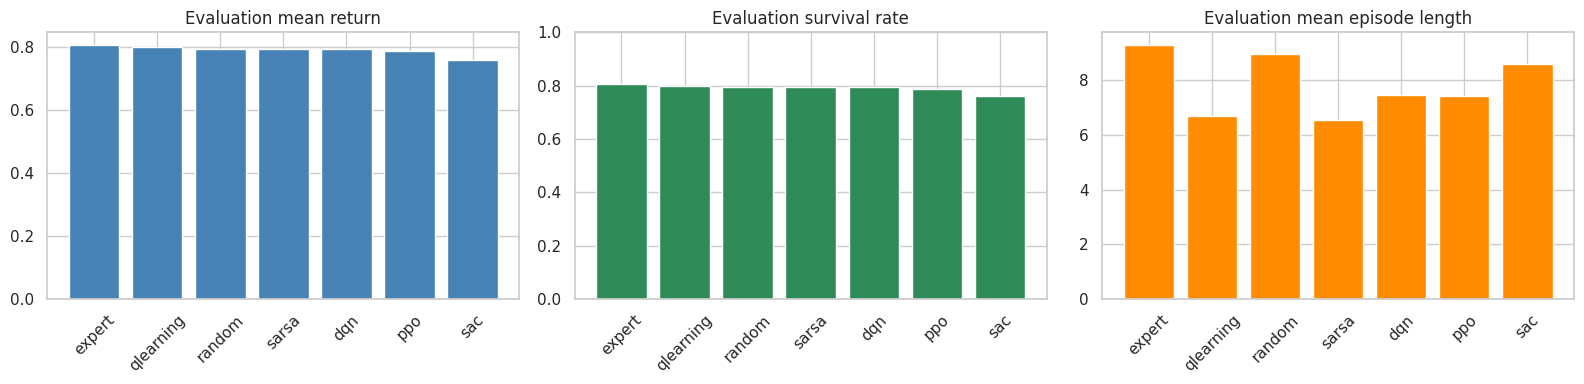

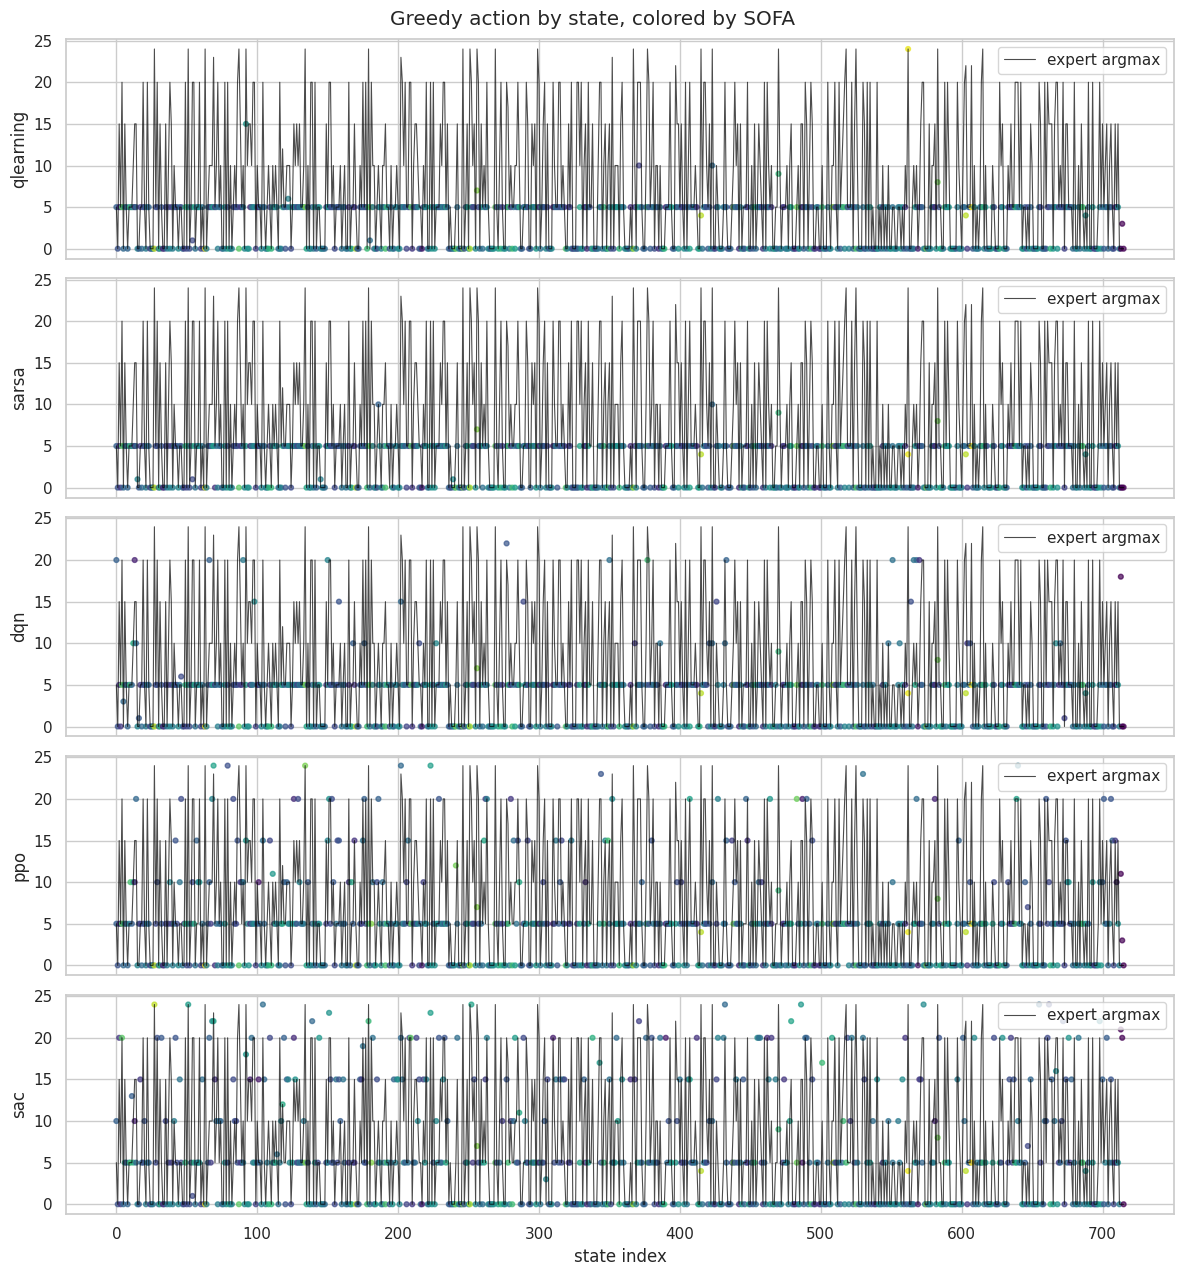

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ordered = eval_df.sort_values("mean_return", ascending=False)

axes[0].bar(ordered["policy"], ordered["mean_return"], color="steelblue")
axes[0].set_title("Evaluation mean return")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(ordered["policy"], ordered["survival_rate"], color="seagreen")
axes[1].set_title("Evaluation survival rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(ordered["policy"], ordered["mean_length"], color="darkorange")
axes[2].set_title("Evaluation mean episode length")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

policy_display_rows = []
for result in results:
    policy_fn = greedy_policy_from_result(result)
    greedy_actions = []
    for state in range(expert_pi.shape[0]):
        admissible = np.where(expert_pi[state] > 0)[0]
        if len(admissible) == 0:
            admissible = np.arange(N_ACTIONS)
        info = {"admissible_actions": admissible.tolist()}
        greedy_actions.append(policy_fn(state, info))
    policy_display_rows.append(
        pd.DataFrame(
            {
                "state": np.arange(expert_pi.shape[0]),
                "sofa": sofa_scores,
                "policy": result["name"],
                "greedy_action": greedy_actions,
                "expert_argmax": np.argmax(expert_pi, axis=1),
            }
        )
    )

policy_display_df = pd.concat(policy_display_rows, ignore_index=True)
fig, axes = plt.subplots(len(results), 1, figsize=(12, 2.6 * len(results)), sharex=True)
if len(results) == 1:
    axes = [axes]
for ax, result in zip(axes, results):
    frame = policy_display_df[policy_display_df["policy"] == result["name"]]
    ax.scatter(frame["state"], frame["greedy_action"], s=12, alpha=0.7, c=frame["sofa"], cmap="viridis")
    ax.plot(frame["state"], frame["expert_argmax"], color="black", linewidth=0.8, alpha=0.7, label="expert argmax")
    ax.set_ylabel(result["name"])
    ax.legend(loc="upper right")
axes[-1].set_xlabel("state index")
plt.suptitle("Greedy action by state, colored by SOFA")
plt.tight_layout()
plt.show()

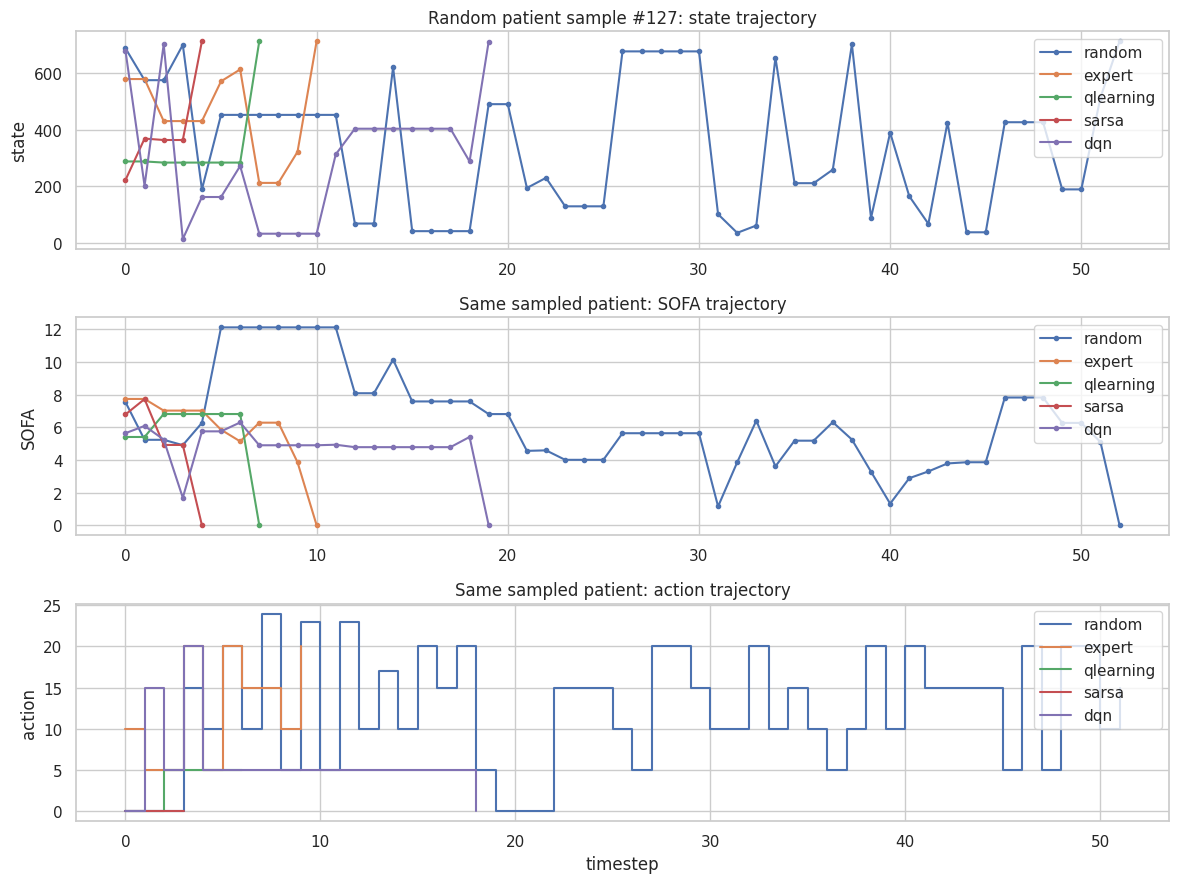

,policy,mean_return,std_return,mean_length,survival_rate
0,expert,0.806667,0.394912,9.293333,0.806667
1,qlearning,0.800000,0.400000,6.680000,0.800000
2,random,0.793333,0.404914,8.960000,0.793333
3,sarsa,0.793333,0.404914,6.566667,0.793333
4,dqn,0.793333,0.404914,7.453333,0.793333
5,ppo,0.786667,0.409661,7.420000,0.786667
6,sac,0.760000,0.427083,8.606667,0.760000


In [18]:
PATIENT_SAMPLE_SEED = 0
POLICIES_TO_SHOW = ["random", "expert"] + [result["name"] for result in results[:3]]
rng = np.random.default_rng(PATIENT_SAMPLE_SEED)
selected_patient_idx = int(rng.integers(EVAL_EPISODES))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

for name in POLICIES_TO_SHOW:
    trace = traces_by_policy[name][selected_patient_idx]
    t_state = np.arange(len(trace["states"]))
    t_action = np.arange(len(trace["actions"]))
    axes[0].plot(t_state, trace["states"], marker="o", ms=3, label=name)
    axes[1].plot(t_state, trace["sofa"], marker="o", ms=3, label=name)
    axes[2].step(t_action, trace["actions"], where="post", label=name)

axes[0].set_title(f"Random patient sample #{selected_patient_idx}: state trajectory")
axes[0].set_ylabel("state")
axes[1].set_title("Same sampled patient: SOFA trajectory")
axes[1].set_ylabel("SOFA")
axes[2].set_title("Same sampled patient: action trajectory")
axes[2].set_ylabel("action")
axes[2].set_xlabel("timestep")
for ax in axes:
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

eval_df